
**Nama:** Muhammad Rafly Romeo Nasution <br>
**Kelas:** 3KA25 <br>
**NPM:** 10123875

---



# MK Praktikum Unggulan Universitas Gunadarma
# Mata Kuliah: Praktikum Terapan Teori Graf (Tingkat 3)

---
# Pertemuan I

## Pengenalan Teori Graf

#### Contoh Kasus 1

Dalam contoh kasus pertama kali ini, kita akan mencoba membangun sebuah graf dengan struktur sebagai berikut.

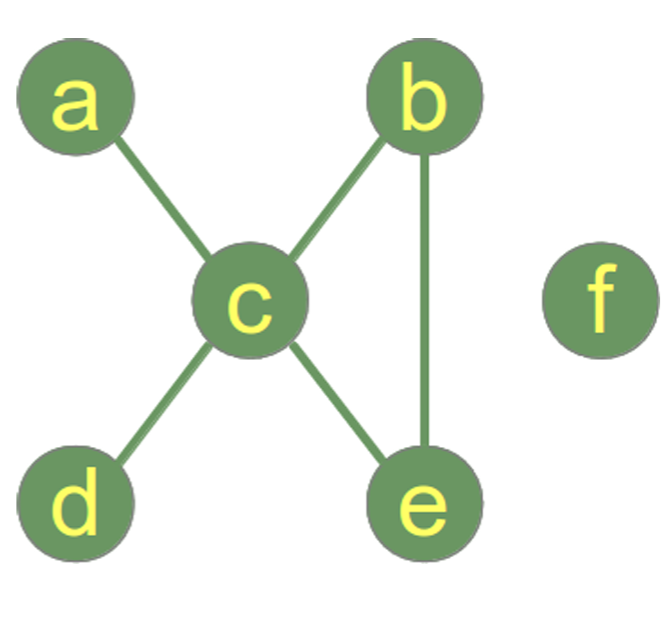

Dalam merepresentasikan bentuk graf tersebut, kita akan membuat 2 fungsi untuk memudahkan proses pembuatan dan pengelolaan graf agar lebih terstruktur dan mudah dipahami.

In [ ]:
## Blok program ini Anda mencoba mendefinisikan node dan hubungan Antara node dalam bentuk obyek.
graph = { "a" : {"c"},
          "b" : {"c", "e"},
          "c" : {"a", "b", "d", "e"},
          "d" : {"c"},
          "e" : {"c", "b"},
          "f" : {}
        }

In [ ]:
## Blok program ini Anda mencoba membuat EDGE dari informasi yang sudah Anda definisikan sebelumnya.
def generate_edges(graph):
    edges = []
    for node in graph:
        for neighbour in graph[node]:
            edges.append({node, neighbour})

    return edges

In [ ]:
print(generate_edges(graph))

[{'c', 'a'}, {'b', 'e'}, {'b', 'c'}, {'b', 'c'}, {'d', 'c'}, {'e', 'c'}, {'a', 'c'}, {'d', 'c'}, {'b', 'e'}, {'e', 'c'}]


In [ ]:
## Blok program ini Anda mendefinisikan sebuah fungsi untuk mengetahui node mana yang tidak memiliki edge
def find_isolated_nodes(graph):
    """ returns a set of isolated nodes. """
    isolated = set()
    for node in graph:
        if not graph[node]:
            isolated.add(node)
    return isolated


---

**Logika:**
Pada kasus pertama, fokus utama kita adalah memahami bagaimana struktur data dasar (seperti *dictionary*) merepresentasikan sebuah graf dan bagaimana cara mendeteksi "node terisolasi" (node yang tidak punya tetangga atau tidak terhubung ke mana pun).

Logikanya begini:

1. Kita punya data graf dalam bentuk *adjacency list* (daftar tetangga).
2. Kita telusuri (iterasi) setiap node yang ada di dalam graf tersebut.
3. Untuk setiap node, kita cek apakah daftar tetangganya kosong atau tidak.
4. Jika kosong (`if not graph[node]`), berarti node tersebut adalah node terisolasi.
5. Node yang terisolasi itu kita kumpulkan ke dalam sebuah wadah (himpunan/set).

**Penjelasan Kode:**

```python
def find_isolated_nodes(graph):
    # 1. Siapkan tempat kosong (set) untuk menampung node terisolasi
    isolated = set()
    
    # 2. Lakukan perulangan untuk mengecek setiap node (key) di dalam dictionary 'graph'
    for node in graph:
        # 3. Cek apakah value dari key tersebut kosong (berarti tidak punya edge/tetangga)
        if not graph[node]:
            # 4. Jika kosong, masukkan node tersebut ke dalam set 'isolated'
            isolated.add(node)
            
    # 5. Kembalikan hasil set yang berisi semua node tanpa teman tadi
    return isolated

```

Dengan fungsi ini, kalau kita punya node "f" yang isinya `{}` (kosong), maka "f" akan terdeteksi sebagai node terisolasi.

---

#### Contoh Kasus 2
Dalam contoh kasus kedua kali ini, kita akan mencoba membangun sebuah graf dan mendapatkan informasi lebih detail
mengenai graf tersebut. Untuk memudahkan, kita akan mendefinisikan sebuah Class dalam bahasa pemrograman python,
dimana Class ini berisi beberapa fungsi yang bisa kita gunakan untuk mengetahui informasi detail mengenai stuktur dari graf yang kita miliki.

In [ ]:
""" A Python Class
A simple Python graph class, demonstrating the essential
facts and functionalities of graphs.
"""


class Graph(object):

    def __init__(self, graph_dict=None):
        """ initializes a graph object
            If no dictionary or None is given,
            an empty dictionary will be used
        """
        if graph_dict == None:
            graph_dict = {}
        self._graph_dict = graph_dict

    def edges(self, vertice):
        """ returns a list of all the edges of a vertice"""
        return self._graph_dict[vertice]

    def all_vertices(self):
        """ returns the vertices of a graph as a set """
        return set(self._graph_dict.keys())

    def all_edges(self):
        """ returns the edges of a graph """
        return self.__generate_edges()

    def add_vertex(self, vertex):
        """ If the vertex "vertex" is not in
            self._graph_dict, a key "vertex" with an empty
            list as a value is added to the dictionary.
            Otherwise nothing has to be done.
        """
        if vertex not in self._graph_dict:
            self._graph_dict[vertex] = []

    def add_edge(self, edge):
        """ assumes that edge is of type set, tuple or list;
            between two vertices can be multiple edges!
        """
        edge = set(edge)
        vertex1, vertex2 = tuple(edge)
        for x, y in [(vertex1, vertex2), (vertex2, vertex1)]:
            if x in self._graph_dict:
                self._graph_dict[x].add(y)
            else:
                self._graph_dict[x] = [y]

    def __generate_edges(self):
        """ A static method generating the edges of the
            graph "graph". Edges are represented as sets
            with one (a loop back to the vertex) or two
            vertices
        """
        edges = []
        for vertex in self._graph_dict:
            for neighbour in self._graph_dict[vertex]:
                if {neighbour, vertex} not in edges:
                    edges.append({vertex, neighbour})
        return edges

    def __iter__(self):
        self._iter_obj = iter(self._graph_dict)
        return self._iter_obj

    def __next__(self):
        """ allows us to iterate over the vertices """
        return next(self._iter_obj)

    def __str__(self):
        res = "vertices: "
        for k in self._graph_dict:
            res += str(k) + " "
        res += "\nedges: "
        for edge in self.__generate_edges():
            res += str(edge) + " "
        return res

In [ ]:
g = { "a" : {"d"},
      "b" : {"c"},
      "c" : {"b", "c", "d", "e"},
      "d" : {"a", "c"},
      "e" : {"c"},
      "f" : {}
    }

In [ ]:
graph = Graph(g)

for vertice in graph:
    print("Edges of vertice {vertice}: ", graph.edges(vertice))

Edges of vertice {vertice}:  {'d'}
Edges of vertice {vertice}:  {'c'}
Edges of vertice {vertice}:  {'b', 'd', 'e', 'c'}
Edges of vertice {vertice}:  {'c', 'a'}
Edges of vertice {vertice}:  {'c'}
Edges of vertice {vertice}:  {}


In [ ]:
graph.add_edge({"ab", "fg"})
graph.add_edge({"xyz", "bla"})

In [ ]:
print("")
print("Vertices of graph:")
print(graph.all_vertices())

print("Edges of graph:")
print(graph.all_edges())


Vertices of graph:
{'b', 'c', 'bla', 'f', 'xyz', 'a', 'd', 'fg', 'e', 'ab'}
Edges of graph:
[{'d', 'a'}, {'b', 'c'}, {'d', 'c'}, {'e', 'c'}, {'c'}, {'ab', 'fg'}, {'xyz', 'bla'}]


---
**Logika:**
Di kasus kedua, logikanya lebih ke arah *Object-Oriented Programming* (OOP). Kita tidak mau cuma pakai *dictionary* biasa, tapi mau buat "cetakan" (Class) sendiri supaya pengelolaan graf lebih rapi.

Logika utamanya:

* **Encapsulation:** Kita membungkus data graf (`_graph_dict`) di dalam sebuah objek.
* **Abstraksi Fungsi:** Kita buat fungsi-fungsi khusus seperti `add_vertex` untuk nambah titik baru dan `add_edge` untuk nambah garis penghubung.
* **Generasi Edge:** Logika unik di sini ada pada fungsi `all_edges`, di mana kode akan menelusuri setiap node dan tetangganya, lalu menyusunnya menjadi pasangan unik supaya tidak ada garis yang terhitung dua kali.

Intinya, di Kasus 2 ini kita belajar cara bikin alat (tools) sendiri buat manipulasi graf sebelum pakai *library* luar.

---

#### Contoh Kasus 3
Dalam contoh kasus ketiga kali ini, kita akan mencoba membangun sebuah graf dengan menggunakan library networkx dan matplotlib.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# Creating a Graph
G = nx.Graph() # Right now G is empty

In [ ]:
G.add_node(1)
G.add_nodes_from([2,3])

In [ ]:
G.add_edge(1,2)

In [ ]:
e = (2,3)
G.add_edge(*e) # * unpacks the tuple
G.add_edges_from([(1,2), (1,3)])

In [ ]:
G.nodes()

NodeView((1, 2, 3))

In [ ]:
G.edges()

EdgeView([(1, 2), (1, 3), (2, 3)])

In [ ]:
G.add_edge(1, 2)
G.add_edge(2, 3)
G.add_edge(3, 4)
G.add_edge(1, 4)
G.add_edge(1, 5)

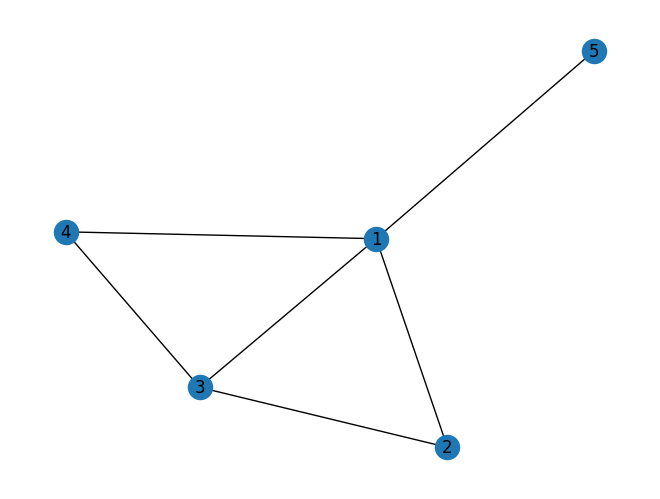

In [ ]:
nx.draw(G, with_labels = True)

In [ ]:
plt.savefig("contoh-graf-1.png")

<Figure size 640x480 with 0 Axes>

---
**Logika:**
Kalau Kasus 1 dan 2 itu cara "manual", di Kasus 3 ini kita pakai cara "instan" tapi profesional, yaitu pakai *library* `networkx`.

Logikanya jauh lebih praktis:

1. **Inisialisasi:** Kita panggil `nx.Graph()` sebagai wadah kosong.
2. **Penyusunan Struktur:** Kita tinggal pakai perintah `add_node` untuk titik dan `add_edge` untuk garis. Logika di belakang layar `networkx` sudah otomatis mengatur hubungan antar objek tersebut.
3. **Visualisasi:** Terakhir, kita pakai logika `nx.draw`. Fungsi ini menghitung koordinat titik-titik (layout) secara otomatis supaya grafnya bisa kita lihat dalam bentuk gambar lewat `matplotlib`.

Tujuan utama kasus ini adalah efisiensi, karena kita nggak perlu lagi mikirin cara simpan data secara manual, cukup panggil fungsi yang sudah ada.

---

Silahkan Anda membuat beberapa graf di bawah ini dengan menggunakan fungsi graf yang telah disediakan.

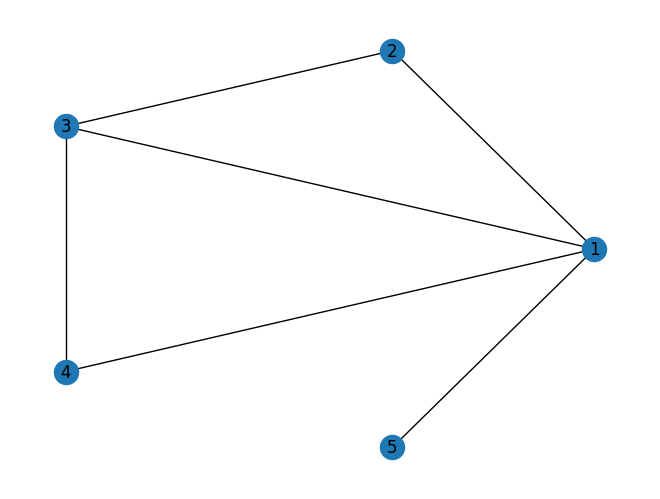

In [ ]:
# drawing in circular layout
nx.draw_circular(G, with_labels = True)

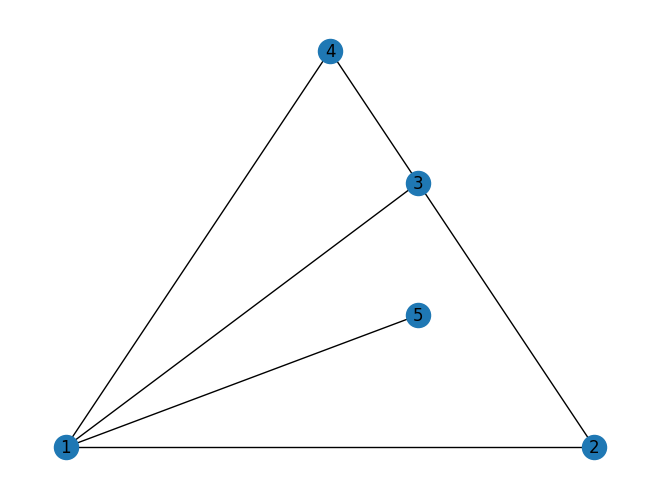

In [ ]:
# Drawing in planar layout
nx.draw_planar(G, with_labels = True)

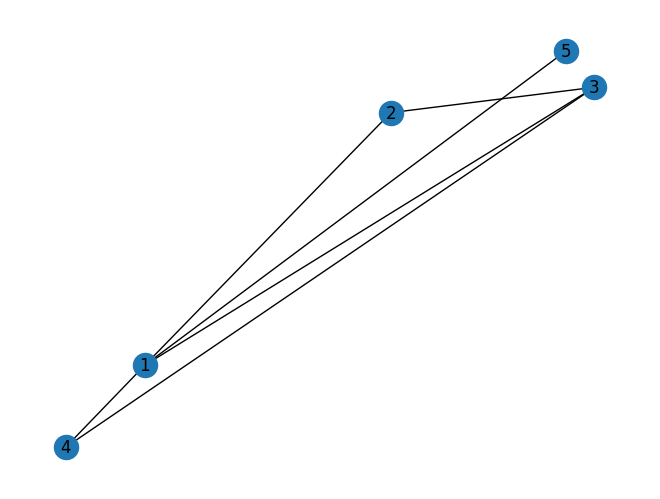

In [ ]:
# Drawing in random layout
nx.draw_random(G, with_labels = True)

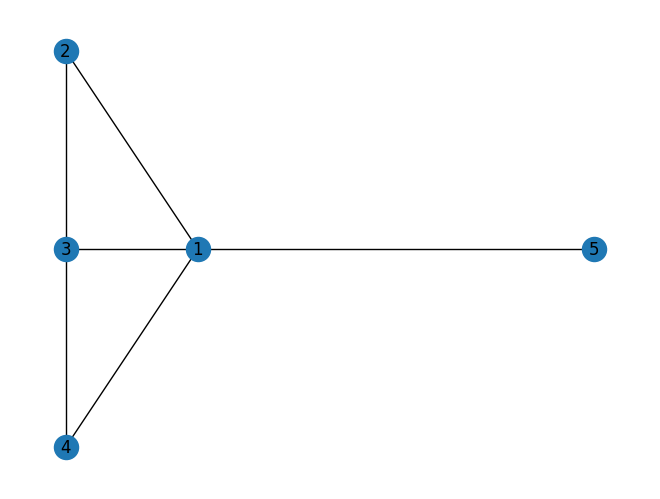

In [ ]:
# Drawing in spectral layout
nx.draw_spectral(G, with_labels = True)

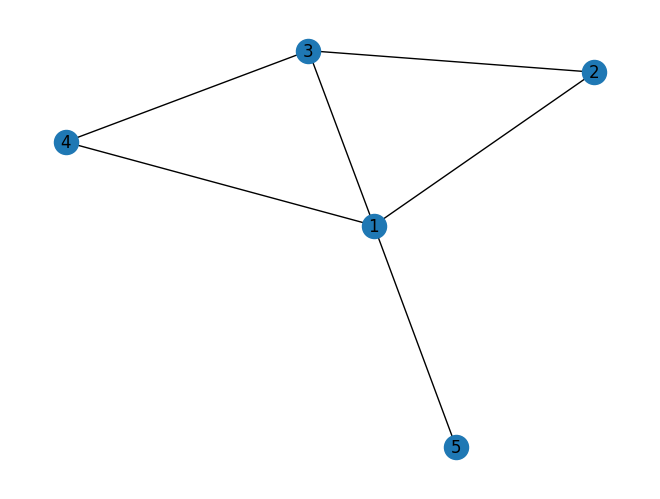

In [ ]:
# Drawing in spring layout
nx.draw_spring(G, with_labels = True)

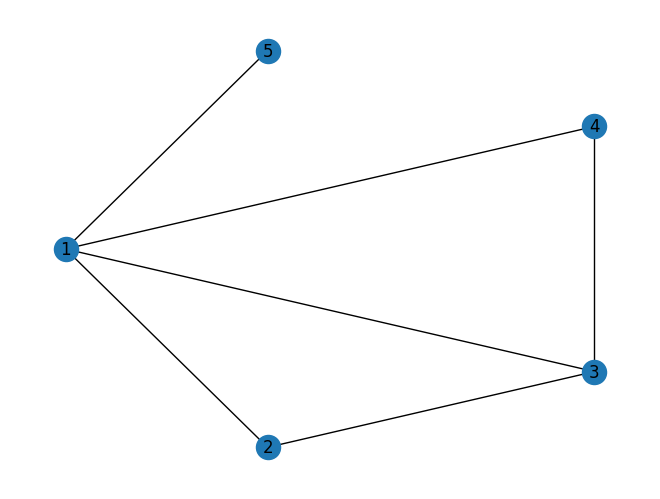

In [ ]:
# Drawing in shell layout
nx.draw_shell(G, with_labels = True)

---

### **Lanjutan Kasus 3: Logika Algoritma Layout Visualisasi**

**Logika Umum:**
Dalam dunia graf, cara kita naruh titik itu krusial supaya informasinya gampang dibaca. NetworkX nyediain beberapa algoritma "Layout" buat nentuin posisi node secara otomatis. Logikanya, fungsi-fungsi ini bakal nerima objek graf `G`, ngitung posisi titiknya, terus nampilinnya lewat `matplotlib`.

Berikut bedanya masing-masing fungsi yang kita pakai:

1. **Circular Layout (`nx.draw_circular`)**
* **Logika:** Node disusun membentuk lingkaran sempurna.
* **Kegunaan:** Cocok kalau kita mau lihat hubungan antar node tanpa ada node yang kelihatan lebih "utama" di tengah. Semuanya ditaruh di posisi yang setara di sekeliling lingkaran.


2. **Planar Layout (`nx.draw_planar`)**
* **Logika:** Algoritma ini bakal berusaha sebisa mungkin supaya garis antar node (*edge*) nggak saling berpotongan atau tabrakan.
* **Kegunaan:** Sangat berguna buat ngecek apakah graf kita itu *planar* (bisa digambar di bidang datar tanpa garis yang tumpang tindih) atau nggak. Kalau grafnya kompleks banget dan emang bukan graf planar, fungsi ini biasanya bakal *error*.


3. **Random Layout (`nx.draw_random`)**
* **Logika:** Sesuai namanya, posisi node ditaruh secara acak di dalam bidang koordinat.
* **Kegunaan:** Jujur, ini jarang dipakai buat analisis serius karena hasilnya biasanya berantakan. Tapi kadang oke buat perbandingan atau kalau kita cuma mau cek distribusi titik secara kasar.


4. **Spectral Layout (`nx.draw_spectral`)**
* **Logika:** Ini agak berat di matematika karena dia pakai *eigenvectors* dari matriks *Laplacian* graf.
* **Kegunaan:** Biasanya graf yang punya kelompok-kelompok tertentu (cluster) bakal kelihatan lebih jelas posisinya pakai layout ini. Titik yang hubungannya kuat bakal cenderung deketan.


5. **Spring Layout (`nx.draw_spring`)**
* **Logika:** Ini yang paling sering dipakai (default). Dia pakai algoritma *Fruchterman-Reingold*. Bayangin titik itu kayak magnet yang saling tolak-menolak, tapi garisnya kayak pegas/per yang narik mereka balik.
* **Kegunaan:** Hasilnya kelihatan paling "alami" dan estetik karena strukturnya tersebar merata dan nggak gampang numpuk.


6. **Shell Layout (`nx.draw_shell`)**
* **Logika:** Mirip lingkaran, tapi bentuknya bisa berlapis-lapis (konsentris). Kalau kita punya grup di dalam node, kita bisa naruh satu grup di lingkaran dalam dan grup lain di lingkaran luar.
* **Kegunaan:** Bagus buat nampilin struktur yang punya hierarki atau tingkatan.



---




---


Copyright © Pengelola MK Praktikum Unggulan (Praktikum DGX), Universitas Gunadarma


https://www.praktikum-hpc.gunadarma.ac.id/